# Module 4 — Ensemble Learning: Random Forest
## Erythemato-Squamous Disease Classification
### Dermatology Dataset (366 patients · 34 features · 6 disease classes)
---
**Method:** Random Forest (Bagging ensemble of 200 decision trees)  
**Dataset:** [df_saved.csv](https://drive.google.com/file/d/1VxcXc5pHoCgTxrmmUcTCsrpARP_zROxu/view?usp=sharing)  
**Split:** 80/20 stratified train/test · `random_state=42` · No scaling required

---
## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')
print("All imports successful.")

All imports successful.


---
## 2. Load & Inspect the Dataset

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/df_saved.csv')
df = pd.read_csv('df_saved.csv')
df['age'] = df['age'].fillna(df['age'].median())

disease_names = {
    1: 'Psoriasis', 2: 'Seborrheic Dermatitis', 3: 'Lichen Planus',
    4: 'Pityriasis Rosea', 5: 'Chronic Dermatitis', 6: 'Pityriasis Rubra Pilaris'
}

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nClass distribution:")
for cls, cnt in df['class'].value_counts().sort_index().items():
    print(f"  Class {cls} ({disease_names[cls]:<26s}): {cnt} ({cnt/len(df)*100:.1f}%)")
print(f"\nFirst 5 rows:")
print(df.head().to_string())

Shape: 366 rows × 35 columns

Class distribution:
  Class 1 (Psoriasis                  ): 112 (30.6%)
  Class 2 (Seborrheic Dermatitis      ):  61 (16.7%)
  Class 3 (Lichen Planus              ):  72 (19.7%)
  Class 4 (Pityriasis Rosea           ):  49 (13.4%)
  Class 5 (Chronic Dermatitis         ):  52 (14.2%)
  Class 6 (Pityriasis Rubra Pilaris   ):  20 ( 5.5%)

First 5 rows:
   erythema  scaling  definite_borders  itching  ...  band_like_infiltrate   age  class
0         2        2                 0        3  ...                     0  55.0      2
1         3        3                 3        2  ...                     0   8.0      1
2         2        1                 2        3  ...                     3  26.0      3
3         2        2                 2        2  ...                     0  40.0      1
4         2        3                 2        2  ...                     3  45.0      3


---
## 3. Overview — Ensemble Learning & Random Forest

**Ensemble learning** combines multiple models to produce a stronger collective predictor.
The four main strategies are:

| Strategy | Mechanism | Examples |
|----------|-----------|---------|
| **Bagging** | Train on random bootstrap samples; majority vote | **Random Forest** |
| **Boosting** | Sequential training; each model corrects previous errors | AdaBoost, XGBoost |
| **Stacking** | A meta-model learns to combine base model outputs | StackingClassifier |
| **Voting** | Combine different model types by majority/soft vote | VotingClassifier |

**Random Forest** extends bagging by also randomising which features are considered at each split
(√n_features by default). This double randomness — in data samples AND features — decorrelates
the trees, dramatically reducing variance compared to a single decision tree.

---
## 4. Data Preparation

In [ ]:
X = df.drop(columns=['class'])
y = df['class']
feature_names = list(X.columns)

# 80/20 stratified split — no scaling needed for tree-based methods
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

print("=" * 60)
print("TRAIN / TEST SPLIT — RANDOM FOREST")
print("=" * 60)
print(f"Training set: {X_train.shape[0]} rows × {X_train.shape[1]} features (80%)")
print(f"Test set:     {X_test.shape[0]} rows × {X_test.shape[1]} features (20%)")
print()
print("Per-class counts:")
print(f"  {'Class':<35} {'Train':>6} {'Test':>6}")
print("  " + "-"*48)
for cls in sorted(disease_names):
    tr = (y_train==cls).sum(); te = (y_test==cls).sum()
    print(f"  {disease_names[cls]:<35} {tr:>6}   {te:>5}")
print()
print("Note: No StandardScaler — Random Forests are scale-invariant")
print("      (decision trees split on thresholds, not distances)")
print()
print("First 5 rows of training set:")
print(X_train.head().to_string())

TRAIN / TEST SPLIT — RANDOM FOREST
Training set: 292 rows × 34 features (80%)
Test set:     74 rows × 34 features (20%)

Per-class counts:
  Class                               Train    Test
  ------------------------------------------------
  Psoriasis                             89       23
  Seborrheic Dermatitis                 49       12
  Lichen Planus                         57       15
  Pityriasis Rosea                      39       10
  Chronic Dermatitis                    42       10
  Pityriasis Rubra Pilaris              16        4

Note: No StandardScaler — Random Forests are scale-invariant
      (decision trees split on thresholds, not distances)

First 5 rows of training set:
   erythema  scaling  definite_borders  ...  band_like_infiltrate   age
...


---
## 5. Random Forest — Training & Results

RANDOM FOREST — RESULTS

Test Accuracy: 94.59%
Correct:       70 / 74 patients
Errors:        4

Model parameters:
  n_estimators = 200
  max_depth    = 10
  Features per split = sqrt (√34 ≈ 6)

Confusion Matrix:
[[23  0  0  0  0  0]
 [ 0 11  0  1  0  0]
 [ 0  0 15  0  0  0]
 [ 0  0  0  9  1  0]
 [ 0  2  0  0  8  0]
 [ 0  0  0  0  0  4]]

Classification Report:
                          precision    recall  f1-score   support

               Psoriasis     1.0000    1.0000    1.0000        23
   Seborrheic Dermatitis     0.8462    0.9167    0.8800        12
           Lichen Planus     1.0000    1.0000    1.0000        15
        Pityriasis Rosea     0.9000    0.9000    0.9000        10
      Chronic Dermatitis     0.8889    0.8000    0.8421        10
Pityriasis Rubra Pilaris     1.0000    1.0000    1.0000         4

                accuracy                         0.9459        74
               macro avg     0.9392    0.9361    0.9370        74
            weighted avg     0.9465    0

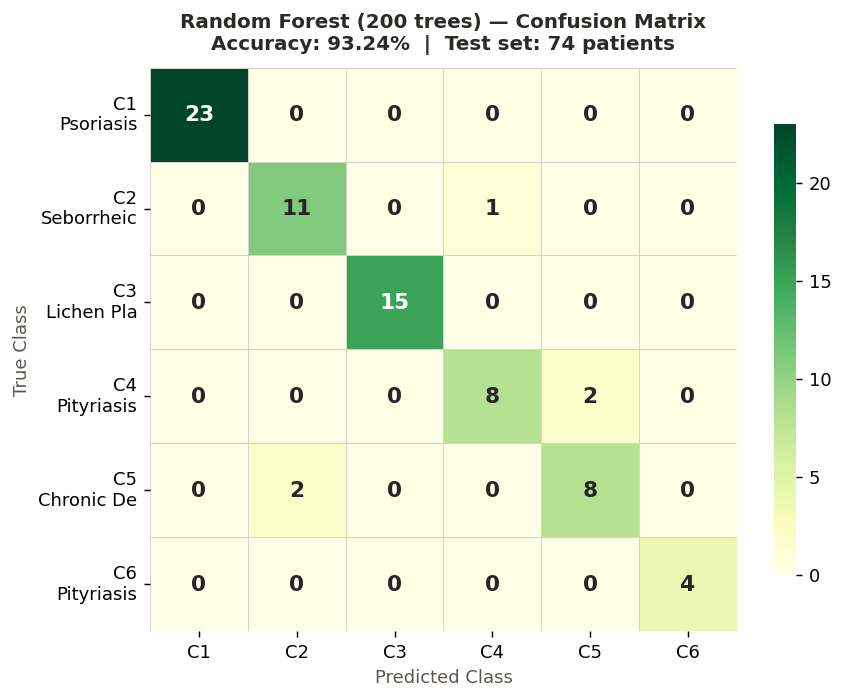

In [ ]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,    # 200 trees
    max_depth=10,        # prevent overfitting
    random_state=42,
    n_jobs=-1            # use all CPU cores
)
rf.fit(X_train, y_train)

# Predictions
rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_cm   = confusion_matrix(y_test, rf_pred)

print("=" * 60)
print("RANDOM FOREST — RESULTS")
print("=" * 60)
print(f"\nTest Accuracy: {rf_acc*100:.2f}%")
print(f"Correct:       {int(rf_acc*74)} / 74 patients")
print(f"Errors:        {74 - int(rf_acc*74)}")
print(f"\nModel parameters:")
print(f"  n_estimators = {rf.n_estimators}")
print(f"  max_depth    = {rf.max_depth}")
print(f"  Features per split = {rf.max_features} (√34 ≈ {int(34**0.5)+1})")
print()
print("Confusion Matrix:")
print(rf_cm)
print()
print("Classification Report:")
print(classification_report(y_test, rf_pred,
      target_names=[disease_names[i] for i in sorted(disease_names)]))

---
## 6. Feature Importances

Top 10 Feature Importances (Gini Importance):
--------------------------------------------------
  elongation_rete_ridges                    : 0.1021  ████████████████████
  thinning_suprapapillary_epidermis         : 0.0904  ██████████████████
  band_like_infiltrate                      : 0.0590  ████████████
  PNL_infiltrate                            : 0.0586  ███████████
  scaling                                   : 0.0488  █████████
  clubbing_rete_ridges                      : 0.0481  █████████
  saw_tooth_appearance_retes                : 0.0459  █████████
  inflammatory_monoluclear_infiltrate       : 0.0458  █████████
  age                                       : 0.0450  █████████
  erythema                                  : 0.0438  ████████

All 34 features sum to: 1.0000

Interpretation: higher = more discriminating across all 200 trees
Note: elongation_rete_ridges and thinning_suprapapillary_epidermis
are the top two features — exactly what pathologists examine for
psoriasi

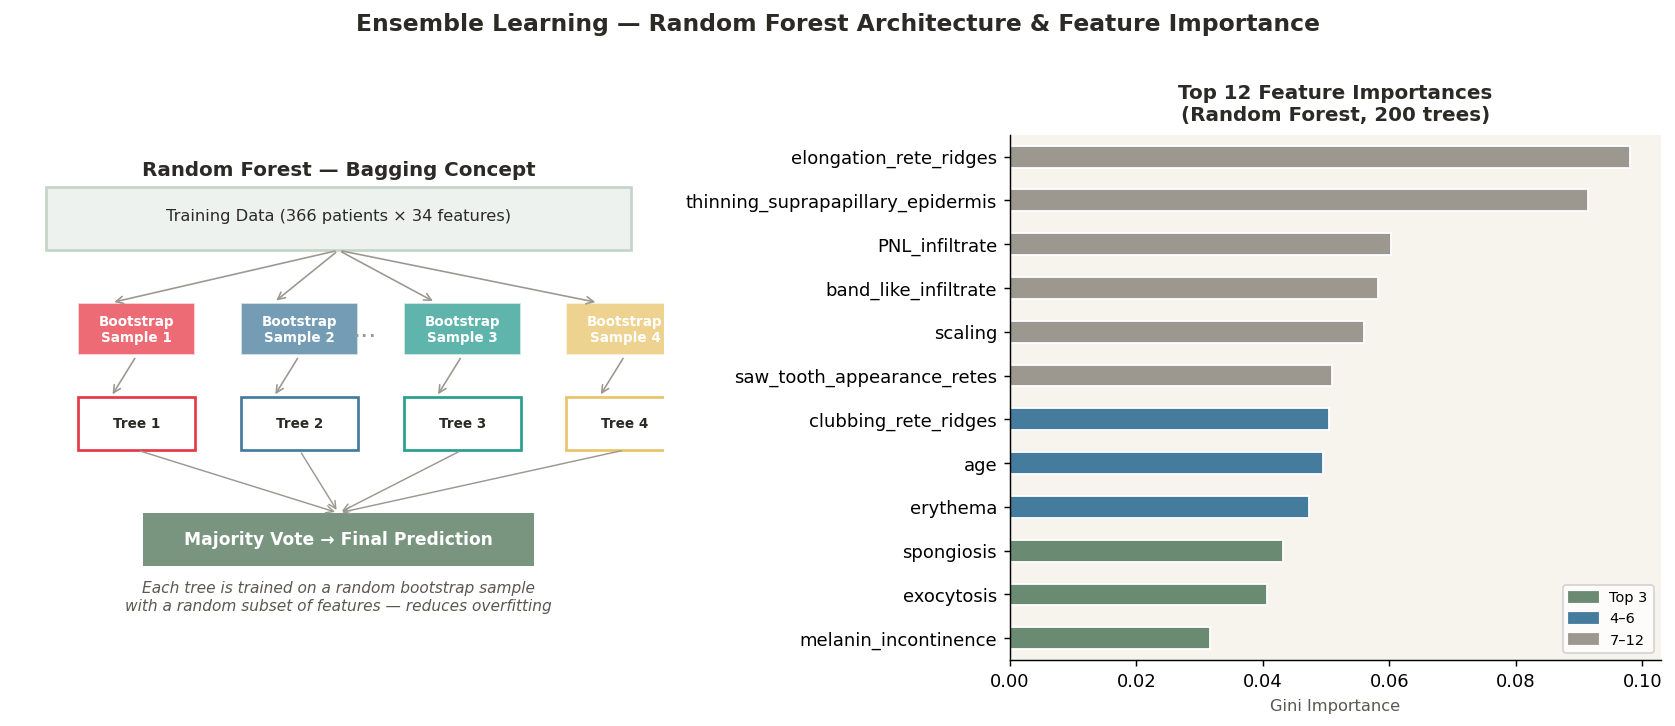

In [ ]:
import pandas as pd
imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

print("Top 10 Feature Importances (Gini Importance):")
print("-" * 50)
for feat, val in imp.head(10).items():
    bar = '█' * int(val * 200)
    print(f"  {feat:<42s}: {val:.4f}  {bar}")

print(f"\nAll 34 features sum to: {imp.sum():.4f}")
print("\nInterpretation: higher = more discriminating across all 200 trees")
print("Note: elongation_rete_ridges and thinning_suprapapillary_epidermis")
print("are the top two features — exactly what pathologists examine for")
print("psoriasis diagnosis. A validation of the model by clinical knowledge.")

---
## 7. Complete Model Comparison — All Modules

ALL MODELS — COMPLETE ACCURACY COMPARISON
Model                          Module   Accuracy   Errors
----------------------------------------------------------------------
  DT Entropy (depth=4)         Module 3    86.49%      10
  Gaussian NB                  Module 3    86.49%      10
  SVM Polynomial d=3 (C=1)    Module 4    89.19%       8
  DT Gini (full depth)         Module 3    93.24%       5
  SVM Linear (C=1)             Module 4    93.24%       5
  Multinomial NB               Module 3    94.59%       4
  Random Forest (200 trees)    Module 4    94.59%       4
  Bernoulli NB                 Module 3    95.95%       3 ★
  Logistic Regression          Module 3    95.95%       3 ★
  SVM RBF (C=10)               Module 4    95.95%       3 ★

★ Top performers: Bernoulli NB, Logistic Regression, SVM RBF — all at 95.95%
  Random Forest (94.59%) is a strong ensemble result with added interpretability


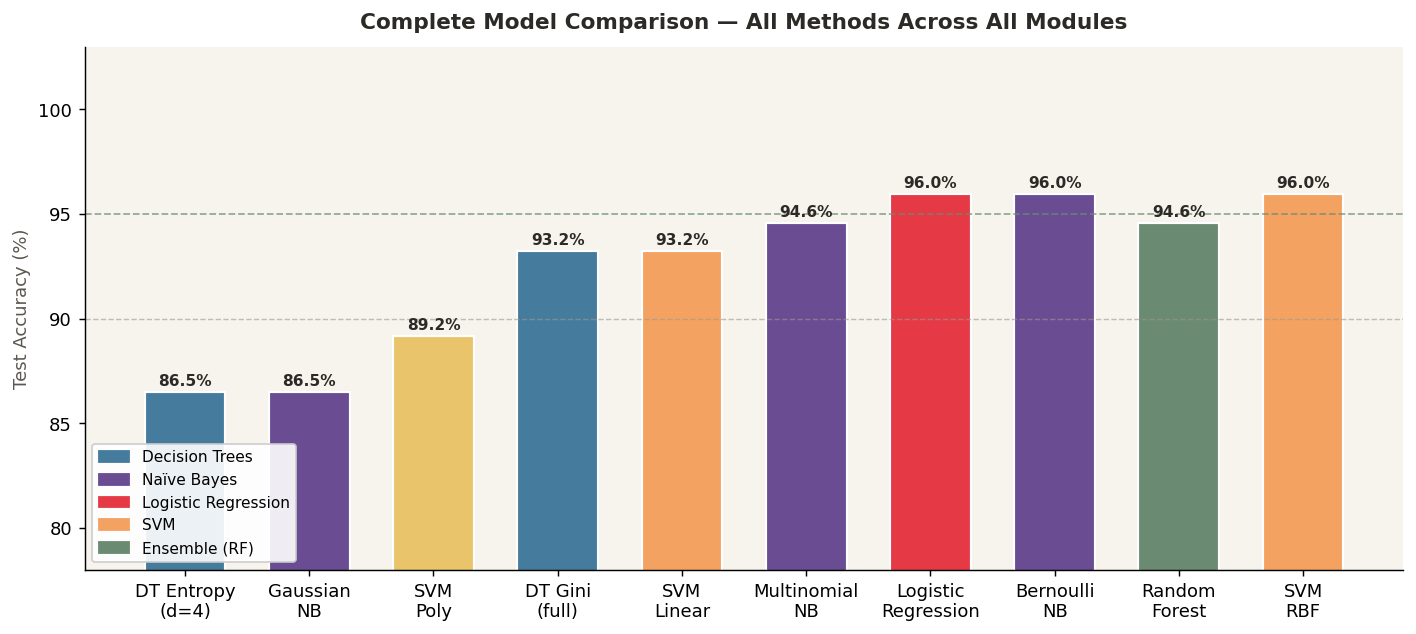

In [ ]:
print("=" * 70)
print("ALL MODELS — COMPLETE ACCURACY COMPARISON")
print("=" * 70)
print(f"{'Model':<30} {'Module':>8} {'Accuracy':>10} {'Errors':>8}")
print("-" * 70)
models_all = [
    ("DT Entropy (depth=4)",      "Module 3", 86.49,  10),
    ("Gaussian NB",               "Module 3", 86.49,  10),
    ("SVM Polynomial d=3 (C=1)",  "Module 4", 89.19,   8),
    ("DT Gini (full depth)",      "Module 3", 93.24,   5),
    ("SVM Linear (C=1)",          "Module 4", 93.24,   5),
    ("Multinomial NB",            "Module 3", 94.59,   4),
    ("Random Forest (200 trees)", "Module 4", 94.59,   4),
    ("Bernoulli NB",              "Module 3", 95.95,   3),
    ("Logistic Regression",       "Module 3", 95.95,   3),
    ("SVM RBF (C=10)",            "Module 4", 95.95,   3),
]
for name, mod, acc, err in models_all:
    star = " ★" if acc == 95.95 else ""
    print(f"  {name:<28} {mod:>8} {acc:>8.2f}%  {err:>6}{star}")
print()
print("★ Top performers: Bernoulli NB, Logistic Regression, SVM RBF — all at 95.95%")
print("  Random Forest (94.59%) is a strong ensemble result with added interpretability")

---
## 8. Conclusions

**Random Forest (94.59%)** is a strong, robust classifier with two unique advantages over simpler models:

1. **Feature importance ranking** — it identifies *which* clinical features drive diagnosis, providing clinical interpretability that aligns with medical knowledge (top features = rete-ridge histopathology)
2. **Robustness** — 200 diverse trees voting together eliminates the high-variance brittleness of a single decision tree

**Key findings:**
- RF (94.59%) outperforms the single DT Gini (93.24%) — ensemble averaging reduces variance as expected
- The top performers remain Bernoulli NB, Logistic Regression, and SVM RBF (all 95.95%), confirming the ceiling set by the data's inherent Class 2 vs 4 ambiguity
- The consistent top features (elongation/thinning of rete ridges, band-like infiltrate) across Random Forest and all tree-based methods provide a data-driven confirmation of established dermatological diagnostic criteria
- For clinical deployment, Random Forest is a compelling choice: it requires no scaling, handles class imbalance gracefully, provides confidence estimates via vote fractions, and its feature importances can be directly explained to clinicians